In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
!pip install numpy pandas matplotlib seaborn pyarrow -q

import os
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\JEON YUNA\my-first\ai-data-bootcamp\D008\d009_outputs


In [ ]:
#파일 가져오기
file_path = r"C:\Users\JEON YUNA\Downloads\한국환경공단_도로 재비산먼지 측정 정보_20260625.csv"

dust = pd.read_csv(file_path, encoding="cp949")  # 한글 CSV는 cp949로 읽어야 안 깨짐

print("데이터 크기:", dust.shape)
print("\n컬럼 목록:", list(dust.columns))
print("\n데이터 타입:")
print(dust.dtypes)
dust.head()

데이터 크기: (1472, 11)

컬럼 목록: ['측정일자', '측정시간', '지역', '지역명', '도로명', '시작점', '종점', '기온', '습도', '재비산먼지 평균농도', '오염범례']

데이터 타입:
측정일자            str
측정시간            str
지역              str
지역명             str
도로명             str
시작점             str
종점              str
기온            int64
습도            int64
재비산먼지 평균농도    int64
오염범례            str
dtype: object


,측정일자,측정시간,지역,지역명,도로명,시작점,종점,기온,습도,재비산먼지 평균농도,오염범례
0,2026-06-01,14:49,서울,송파구,양재대로,서울특별시 송파구 가락동 520천,서울특별시 송파구 방이동 89-29도,30,31,2,매우좋음
1,2026-06-01,14:38,서울,송파구,중대로,서울특별시 송파구 오금동 3-6도,서울특별시 송파구 가락동 616-1천,30,31,3,매우좋음
2,2026-06-01,14:17,서울,송파구,동남로,서울특별시 송파구 문정동 150-14 도,서울특별시 송파구 방이동 434-1임,30,32,18,매우좋음
3,2026-06-01,14:05,서울,송파구,문정로,서울특별시 송파구 마천동 산21-1 도,서울특별시 송파구 문정동 119-4 도,29,32,6,매우좋음
4,2026-06-01,13:43,경기,하남시,서하남로,경기도 하남시 교산동 104-3수,경기도 하남시 감북동 447-4수,30,31,5,매우좋음


In [5]:
# 예제: 품질 리포트 함수 v2 — 수치형 컬럼에 IQR 이상치 비율을 추가
def quality_report_full(df: pd.DataFrame, name: str = "df", missing_threshold: float = 30.0) -> pd.DataFrame:
    '''v1에 수치형 이상치 비율(IQR)과 의심 타입 컬럼 표시를 추가합니다.'''
    n_rows = len(df)
    base = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    base["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    # object 컬럼이 실제로는 날짜로 파싱되는지 의심 표시
    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col],format='mixed', errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    base["maybe_datetime"] = base.index.isin(suspicious_datetime)
    base["warning"] = base["missing_pct"].apply(
    lambda pct: "⚠" if pct > missing_threshold else "")

    print(f"[품질 리포트(완전판)] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return base

In [6]:
qr_dust = quality_report_full(dust, "dust")
qr_dust

[품질 리포트(완전판)] dust
  행 수: 1,472  /  열 수: 11
  완전 중복 행: 0건
  📌 날짜로 보이는 object 컬럼: ['측정일자', '측정시간']


,dtype,missing,missing_pct,n_unique,outlier_pct_iqr,maybe_datetime,warning
측정일자,str,0,0.00,18,NaN,True,
측정시간,str,0,0.00,440,NaN,True,
지역,str,0,0.00,14,NaN,False,
지역명,str,2,0.14,143,NaN,False,
도로명,str,0,0.00,1167,NaN,False,
시작점,str,0,0.00,1376,NaN,False,
종점,str,0,0.00,1393,NaN,False,
기온,int64,0,0.00,16,0.00,False,
습도,int64,0,0.00,57,0.00,False,
재비산먼지 평균농도,int64,0,0.00,92,9.24,False,


In [10]:
dust['재비산먼지 평균농도'].describe()

count    1472.000000
mean       13.841712
std        31.414383
min         1.000000
25%         4.000000
50%         7.000000
75%        12.000000
max       541.000000
Name: 재비산먼지 평균농도, dtype: float64

지역명결측치는 그냥 삭제하고, 기온, 습도 pct가 숫자로 나오긴 해서 describe로 확인해보니 이상치처럼 보이지는 않아서 그냥 두는 것으로 한다. 그리고 재비산먼지 평균농도에서도 이상치가 발견이 되기는 했는데, 컬럼 특성상 유의한 값일 수도 있겠다는 생각이 들어서 따로 처리하지 않을 예정이다. 
결국, 측정일자/시간을 날짜형으로 바꾸고, 지역명에 있던 결측값들을 제거하는 것으로 정제를 하면 될 것 같다. 

In [13]:
# dtype 변경, 결측치 제거하기
def b_parse_date(df): return df.assign(
    date=pd.to_datetime(df["측정일자"], format="mixed", errors="coerce")
).drop(columns=["측정일자"])
def b_parse_time(df): return df.assign(
    time=pd.to_datetime(df["측정시간"], format="%H:%M", errors="coerce").dt.time
).drop(columns=["측정시간"])

dust_clean = dust.copy()

dust_clean = (
    dust
    .pipe(b_parse_date)
    .pipe(b_parse_time)
    .pipe(lambda d: d[d["지역명"].notna()])    
    .reset_index(drop=True)
)

print(f"정제 전: {dust.shape}  →  정제 후: {dust_clean.shape}")
dust_clean

정제 전: (1472, 11)  →  정제 후: (1470, 11)


,지역,지역명,도로명,시작점,종점,기온,습도,재비산먼지 평균농도,오염범례,date,time
0,서울,송파구,양재대로,서울특별시 송파구 가락동 520천,서울특별시 송파구 방이동 89-29도,30,31,2,매우좋음,2026-06-01,14:49:00
1,서울,송파구,중대로,서울특별시 송파구 오금동 3-6도,서울특별시 송파구 가락동 616-1천,30,31,3,매우좋음,2026-06-01,14:38:00
2,서울,송파구,동남로,서울특별시 송파구 문정동 150-14 도,서울특별시 송파구 방이동 434-1임,30,32,18,매우좋음,2026-06-01,14:17:00
3,서울,송파구,문정로,서울특별시 송파구 마천동 산21-1 도,서울특별시 송파구 문정동 119-4 도,29,32,6,매우좋음,2026-06-01,14:05:00
4,경기,하남시,서하남로,경기도 하남시 교산동 104-3수,경기도 하남시 감북동 447-4수,30,31,5,매우좋음,2026-06-01,13:43:00
...,...,...,...,...,...,...,...,...,...,...,...
1465,인천,강화군,길상로,인천광역시 강화군 길상면 온수리 550-4도,인천광역시 강화군 길상면 초지리 1934-2 답,25,56,72,좋음,2026-06-25,15:40:00
1466,인천,강화군,중앙로,인천광역시 강화군 강화읍 갑곳리 849 대,인천광역시 강화군 내가면 외포리 547-37잡,26,55,31,매우좋음,2026-06-25,14:54:00
1467,인천,강화군,강화대로,경기도 김포시 월곶면 성동리,인천광역시 강화군 하점면 신봉리 50-6 전,26,54,49,매우좋음,2026-06-25,14:33:00
1468,경기,김포시,마송로,경기도 김포시 통진읍 마송리 159-37 임,경기도 김포시 통진읍 마송리 592-9도,26,56,541,매우나쁨,2026-06-25,14:06:00


In [16]:
plt.rcParams["font.family"] = "Malgun Gothic" 

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [24]:
# 1. 시간대별 패턴 — "언제 제일 심하나"
hourly=dust_clean.groupby("time")["재비산먼지 평균농도"].mean().sort_values(ascending=False)
# 2. 지역별 비교 — "어디가 제일 심하나"
region=dust_clean.groupby("지역명")["재비산먼지 평균농도"].agg(["mean", "max", "count"]).sort_values("mean", ascending=False)
# 3. 기온/습도와의 관계 — "날씨가 영향을 주나"
corr=dust_clean[["기온", "습도", "재비산먼지 평균농도"]].corr()
# 4. 오염범례 분포 — "전체적으로 심각한 수준인가"
grade_ratio=dust_clean["오염범례"].value_counts(normalize=True) * 100

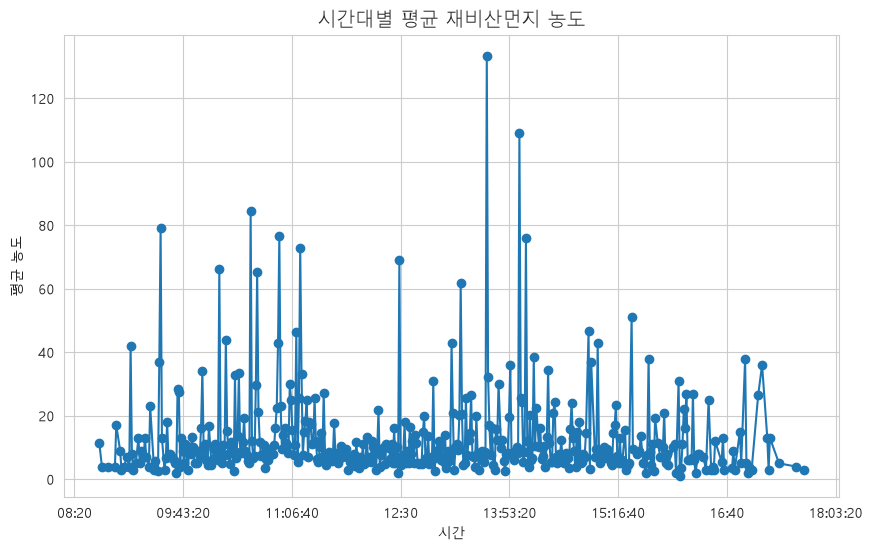

In [19]:
# 1. 시간대별 평균 농도
plt.figure(figsize=(10, 6))
hourly.sort_index().plot(kind="line", marker="o")
plt.title("시간대별 평균 재비산먼지 농도", fontsize=14)
plt.xlabel("시간")
plt.ylabel("평균 농도")
plt.grid(True)
plt.show()

전체적으로 8~20 사이 낮은 값이 기본인데, 13:53:20 근처에서 130 넘게 확 튀는 스파이크가 하나 있다. 뚜렷한 "출퇴근 시간대(아침/저녁)가 높다" 같은 패턴은 안 보이고, 오히려 하루 종일 낮은 값 사이사이 무작위로 스파이크가 튀는 모양임 → "시간대 자체보다는, 특정 순간(공사·통행량 급증 등 돌발상황)이 원인일 가능성"이 더 커 보인다

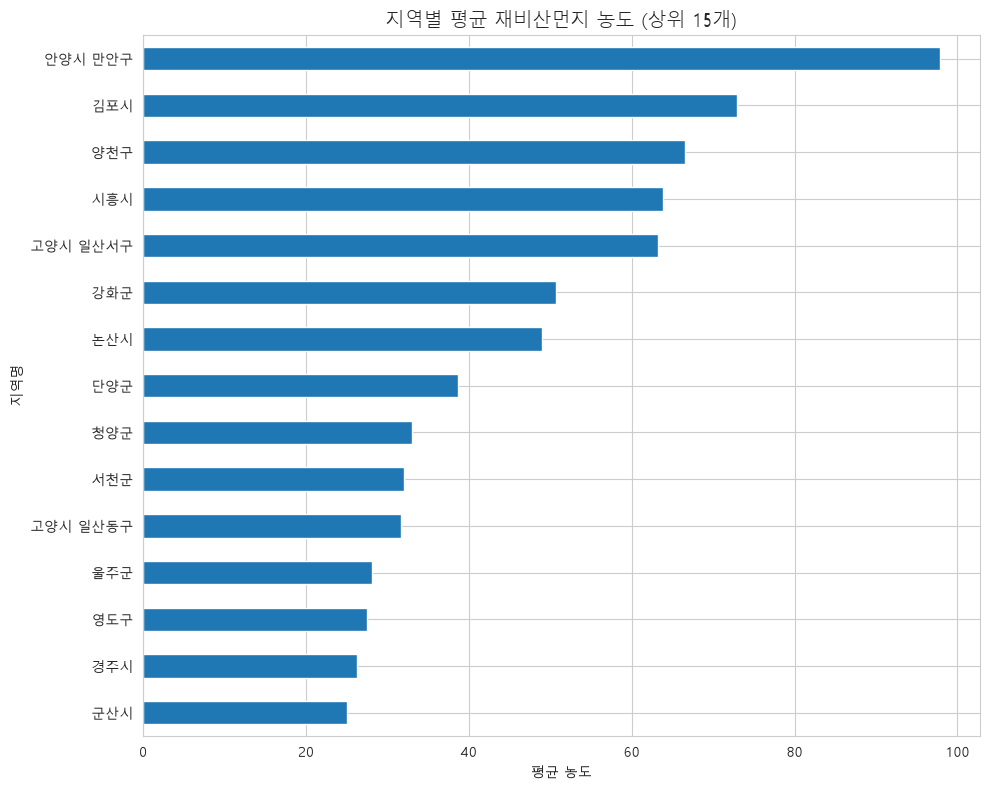

In [26]:
# 2. 지역별 평균 농도
plt.figure(figsize=(10, 8))
region["mean"].sort_values(ascending=True).tail(15).plot(kind="barh")
plt.title("지역별 평균 재비산먼지 농도 (상위 15개)", fontsize=14)
plt.xlabel("평균 농도")
plt.tight_layout()
plt.show()

"인양시"(아마 화면이 잘려서 "고양시"가 겹쳐 보이는 것 같아요, x축 라벨 겹침 확인 필요)가 압도적으로 1위(~98)이고, 그 다음부터는 완만하게 떨어지는 롱테일 형태이다.(지역 너무 많아서 생략) 상위 3~4개 지역이 나머지보다 확실히 높고, 대부분 지역은 20 이하에 몰려있다 → "일부 지역에 재비산먼지가 집중된다"는 뚜렷한 지역 편차가 보인다.

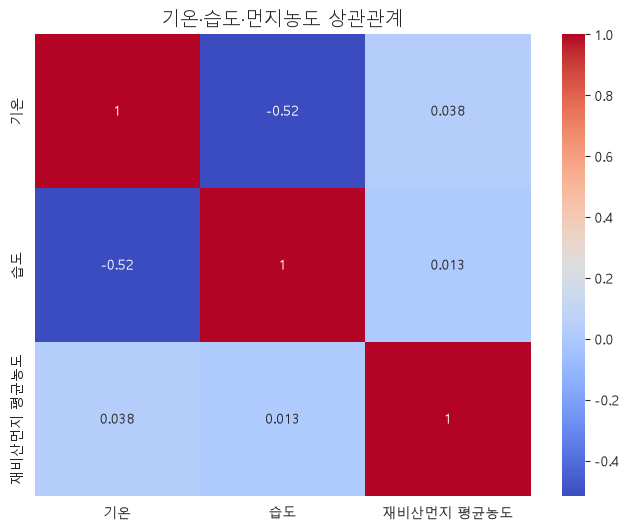

In [22]:
# 3. 기온·습도·농도 상관관계
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("기온·습도·먼지농도 상관관계", fontsize=14)
plt.show()

"기온/습도가 먼지농도에 영향을 주는가"는 둘 다 거의 0(0.038, 0.013) 이라 사실상 관계가 없어보인다.

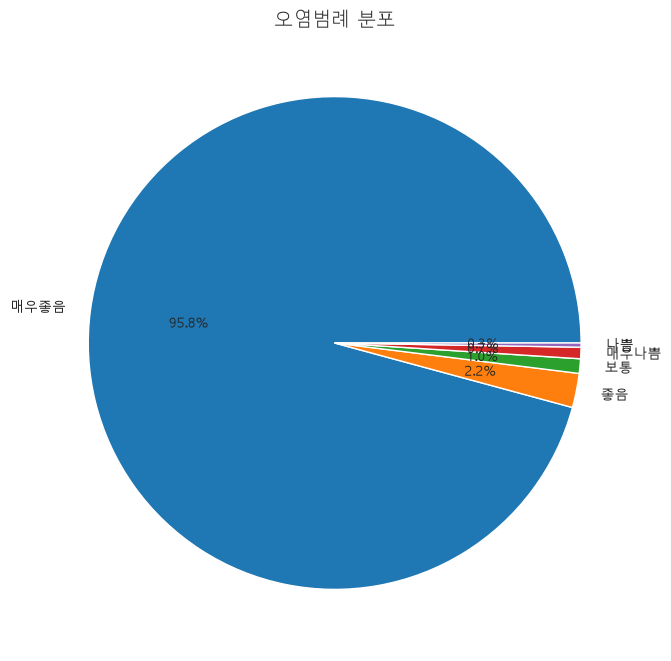

In [23]:
# 4. 오염범례 분포
plt.figure(figsize=(8, 8))
grade_ratio.plot(kind="pie", autopct="%.1f%%")
plt.title("오염범례 분포", fontsize=14)
plt.ylabel("")
plt.show()

"매우좋음"이 95.8%로 압도적이다. 나쁨/매우나쁨 등급은 다 합쳐도 2% 안팎일 것. → "전체적으로는 대부분 시간·지역에서 양호한 수준이고, 극히 일부 구간에서만 심각하게 튄다"는 결론을 낼 수 있다. 이건 1번 그래프(가끔 스파이크)랑 2번 그래프(일부 지역 집중)랑 같은 이야기를 하고 있음. 즉, "평상시엔 괜찮은데, 특정 시간·특정 지역에서만 국지적으로 심하다"로 볼 수 있을 것 같다. 